In [1]:
import torch 
from torch import nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = 'mps' if torch.mps.is_available() else 'cpu'
torch.mps.manual_seed(1234)
torch.manual_seed(1234)

In [2]:
california = fetch_california_housing()
X = california.data
y = california.target.reshape(-1, 1)

In [3]:
X[:10], y[:10]

(array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
          1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
          3.78800000e+01, -1.22230000e+02],
        [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
          9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
          3.78600000e+01, -1.22220000e+02],
        [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
          1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
          3.78500000e+01, -1.22240000e+02],
        [ 5.64310000e+00,  5.20000000e+01,  5.81735160e+00,
          1.07305936e+00,  5.58000000e+02,  2.54794521e+00,
          3.78500000e+01, -1.22250000e+02],
        [ 3.84620000e+00,  5.20000000e+01,  6.28185328e+00,
          1.08108108e+00,  5.65000000e+02,  2.18146718e+00,
          3.78500000e+01, -1.22250000e+02],
        [ 4.03680000e+00,  5.20000000e+01,  4.76165803e+00,
          1.10362694e+00,  4.13000000e+02,  2.13989637e+00,
          3.78500000e+01, -1.22250000e+02],
        [ 3.6591

In [4]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device=device)

In [5]:
def plot_predictions(
        train_data=X_train, train_labels=y_train, 
        test_data=X_test, test_labels=y_test, 
        predictions=None
    ):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data.cpu(), train_labels.cpu(), c='b', s=4, label='Training dataset')
    plt.scatter(test_data.cpu(), test_labels.cpu(), c='g', s=4, label='Test dataset')
    if predictions is not None:
        plt.scatter(test_data.cpu(), predictions.cpu(), c='r', s=4, label='Predictions')
    plt.legend(prop={'size':14})
    plt.show()

In [6]:
class LinearRegression(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weight = nn.Parameter(torch.randn(1, device=device), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, device=device), requires_grad=True)
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.weight * X + self.bias
    
model_0 = LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([-0.0516], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([-2.0092], device='mps:0', requires_grad=True)]

In [7]:
# plot_predictions(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [8]:
X_train_tensor.shape

torch.Size([16512, 8])

### Model 0: vanilla linear reg -- manual

In [9]:
class LinearRegression(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weights = nn.Parameter(torch.randn(8, 1, device=device), requires_grad=True)
        self.biases = nn.Parameter(torch.randn(1, device=device), requires_grad=True)
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return torch.matmul(X, self.weights)  + self.biases
    
model_0 = LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([[-1.4922],
         [-1.0044],
         [ 2.1860],
         [ 1.1292],
         [-0.2513],
         [-0.6885],
         [ 2.1152],
         [ 0.3479]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([0.1431], device='mps:0', requires_grad=True)]

In [10]:
loss_function = nn.L1Loss()
# loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(), lr=0.01
)
epochs = 1000

train_losses, test_losses, epoch = [], [], []
for i in range(epochs):
    model_0.train()
    y_pred = model_0(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test_tensor)
        test_loss = loss_function(test_pred, y_test_tensor)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        epoch.append(i)
        if i % 10 == 0:
            print(f'Epoch: {i} | Train MAE: {loss} | Test MAE: {test_loss}')

Epoch: 0 | Train MAE: 3.5066871643066406 | Test MAE: 3.513856887817383
Epoch: 10 | Train MAE: 3.4284937381744385 | Test MAE: 3.433858871459961
Epoch: 20 | Train MAE: 3.351128101348877 | Test MAE: 3.354771852493286
Epoch: 30 | Train MAE: 3.2747573852539062 | Test MAE: 3.2768747806549072
Epoch: 40 | Train MAE: 3.199267864227295 | Test MAE: 3.200070381164551
Epoch: 50 | Train MAE: 3.1246466636657715 | Test MAE: 3.1243069171905518
Epoch: 60 | Train MAE: 3.0511739253997803 | Test MAE: 3.0496249198913574
Epoch: 70 | Train MAE: 2.978762149810791 | Test MAE: 2.975998878479004
Epoch: 80 | Train MAE: 2.907597064971924 | Test MAE: 2.903599739074707
Epoch: 90 | Train MAE: 2.837696075439453 | Test MAE: 2.832265615463257
Epoch: 100 | Train MAE: 2.768977642059326 | Test MAE: 2.762188196182251
Epoch: 110 | Train MAE: 2.701542377471924 | Test MAE: 2.6935791969299316
Epoch: 120 | Train MAE: 2.635136127471924 | Test MAE: 2.626143455505371
Epoch: 130 | Train MAE: 2.5700223445892334 | Test MAE: 2.560237646

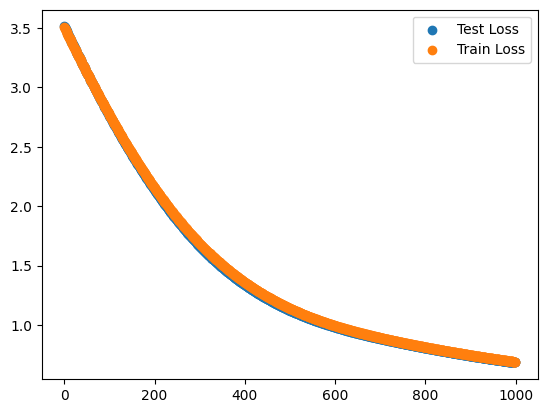

In [11]:
plt.scatter(epoch, test_losses, label="Test Loss")
plt.scatter(epoch, train_losses, label="Train Loss")
plt.legend()
plt.show()

### Model 1: vanilla linear -- nn.linear direct

trying early stopping

In [12]:
model_1 = nn.Linear(in_features=8, out_features=1).to(device)
list(model_1.parameters())

[Parameter containing:
 tensor([[-0.3331, -0.0694, -0.1698, -0.0943, -0.3123,  0.1419, -0.3169, -0.0225]],
        device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([0.1229], device='mps:0', requires_grad=True)]

In [13]:
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01)
loss_function = nn.L1Loss()

epochs = 1000
patience, min_delta = 20, 0.0001
test_losses, train_losses, epoch_counts = [], [], []
best_test_loss, epochs_without_improvement = float('inf'), 0

for i in range(epochs):
    model_1.train()
    y_prediction = model_1(X_train_tensor)
    train_loss = loss_function(y_prediction, y_train_tensor)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_prediction = model_1(X_test_tensor)
        test_loss = loss_function(test_prediction, y_test_tensor)

        if test_loss < (best_test_loss - min_delta):
            best_test_loss = test_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement > patience:
                print(f'Stopping early, best test loss: {best_test_loss:.4f}')
                break

        test_losses.append(test_loss.item())
        train_losses.append(train_loss.item())
        epoch_counts.append(i)

        if i % 10 == 0:
            print(f'Epoch: {i} | Train MAE: {train_loss} | Test MAE: {test_loss}')

Epoch: 0 | Train MAE: 1.9686657190322876 | Test MAE: 1.924908995628357
Epoch: 10 | Train MAE: 1.881231427192688 | Test MAE: 1.838623046875
Epoch: 20 | Train MAE: 1.797110915184021 | Test MAE: 1.755311369895935
Epoch: 30 | Train MAE: 1.7165313959121704 | Test MAE: 1.6759283542633057
Epoch: 40 | Train MAE: 1.639405608177185 | Test MAE: 1.6002540588378906
Epoch: 50 | Train MAE: 1.5657161474227905 | Test MAE: 1.5281715393066406
Epoch: 60 | Train MAE: 1.495742917060852 | Test MAE: 1.4598208665847778
Epoch: 70 | Train MAE: 1.4290097951889038 | Test MAE: 1.3950098752975464
Epoch: 80 | Train MAE: 1.3656535148620605 | Test MAE: 1.3337581157684326
Epoch: 90 | Train MAE: 1.3057159185409546 | Test MAE: 1.275877833366394
Epoch: 100 | Train MAE: 1.2489674091339111 | Test MAE: 1.2207788228988647
Epoch: 110 | Train MAE: 1.195046305656433 | Test MAE: 1.168387532234192
Epoch: 120 | Train MAE: 1.1436551809310913 | Test MAE: 1.1186422109603882
Epoch: 130 | Train MAE: 1.0949311256408691 | Test MAE: 1.07136

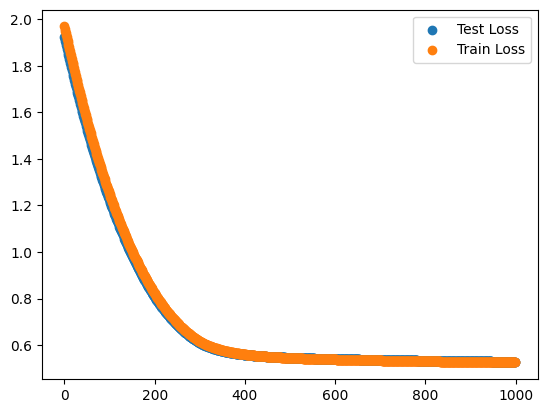

In [14]:
plt.scatter(epoch, test_losses, label="Test Loss")
plt.scatter(epoch, train_losses, label="Train Loss")
plt.legend()
plt.show()

### Model 2: moving to deep models 

learning non linear patterns

In [11]:
class HousingDNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layers = nn.Sequential(
            nn.Linear(8, 64), 
            nn.ReLU(),
            nn.Linear(64, 32), 
            nn.Linear(32, 1)
        )
     
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.layers(X)

In [12]:
model_2 = HousingDNN()
model_2.to(device)
num_params = sum(p.numel() for p in model_2.parameters())
print(f'Number of parameters: {num_params}')

Number of parameters: 2689


In [13]:
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)
loss_function = nn.L1Loss()

epochs = 1000
patience, min_delta, best_test_loss, epochs_without_improvement = 20, 0.0001, float('inf'), 0
test_losses, train_losses, epoch_counts = [], [], []

for i in range(epochs):
    model_2.train()
    train_prediction = model_2(X_train_tensor)
    train_loss = loss_function(train_prediction, y_train_tensor)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_prediction = model_2(X_test_tensor)
        test_loss = loss_function(test_prediction, y_test_tensor)

        if test_loss < (best_test_loss - min_delta):
            best_test_loss = test_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement > patience:
                print(f'Stopping early, best test loss: {best_test_loss:.4f}')
                break
        test_losses.append(test_loss.item())
        train_losses.append(train_loss.item())
        epoch_counts.append(i)
        if i % 10 == 0:
            print(f'Epoch: {i} | Train MAE: {train_loss} | Test MAE: {test_loss}')



Epoch: 0 | Train MAE: 2.2034759521484375 | Test MAE: 2.155085563659668
Epoch: 10 | Train MAE: 1.878053903579712 | Test MAE: 1.8306456804275513
Epoch: 20 | Train MAE: 1.5460983514785767 | Test MAE: 1.4964332580566406
Epoch: 30 | Train MAE: 1.2306468486785889 | Test MAE: 1.1906356811523438
Epoch: 40 | Train MAE: 1.00632643699646 | Test MAE: 0.9800314903259277
Epoch: 50 | Train MAE: 0.8731492757797241 | Test MAE: 0.8544816970825195
Epoch: 60 | Train MAE: 0.7942579388618469 | Test MAE: 0.7815041542053223
Epoch: 70 | Train MAE: 0.7456923723220825 | Test MAE: 0.7361419200897217
Epoch: 80 | Train MAE: 0.7122329473495483 | Test MAE: 0.7058488130569458
Epoch: 90 | Train MAE: 0.6860190629959106 | Test MAE: 0.681725800037384
Epoch: 100 | Train MAE: 0.6629286408424377 | Test MAE: 0.660305380821228
Epoch: 110 | Train MAE: 0.6426199674606323 | Test MAE: 0.6415098905563354
Epoch: 120 | Train MAE: 0.6251581311225891 | Test MAE: 0.625541627407074
Epoch: 130 | Train MAE: 0.6103010773658752 | Test MAE: 0

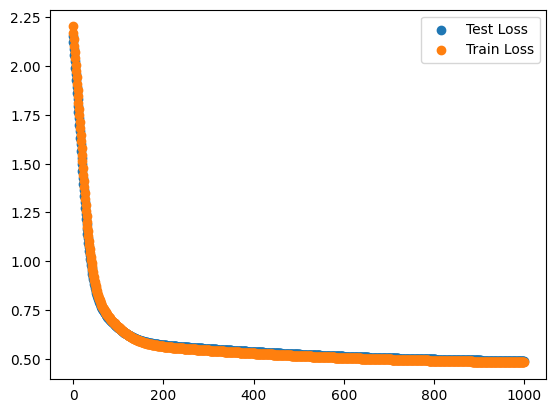

In [17]:
plt.scatter(epoch_counts, test_losses, label="Test Loss")
plt.scatter(epoch_counts, train_losses, label="Train Loss")
plt.legend()
plt.show()

Number of parameters: 2689
Epoch: 0 | Train MAE: 1.9567883014678955 | Test MAE: 1.484259843826294
Epoch: 10 | Train MAE: 0.6885868906974792 | Test MAE: 0.6947832703590393
Epoch: 20 | Train MAE: 0.5933151841163635 | Test MAE: 0.5768110752105713
Epoch: 30 | Train MAE: 0.5196951627731323 | Test MAE: 0.5122501850128174
Epoch: 40 | Train MAE: 0.473064661026001 | Test MAE: 0.47461119294166565
Epoch: 50 | Train MAE: 0.45124372839927673 | Test MAE: 0.4595243036746979
Epoch: 60 | Train MAE: 0.4389384090900421 | Test MAE: 0.4478893280029297
Epoch: 70 | Train MAE: 0.43061816692352295 | Test MAE: 0.4376738667488098
Epoch: 80 | Train MAE: 0.42519813776016235 | Test MAE: 0.43205663561820984
Epoch: 90 | Train MAE: 0.4201756417751312 | Test MAE: 0.4267629384994507
Epoch: 100 | Train MAE: 0.41481032967567444 | Test MAE: 0.42134812474250793
Epoch: 110 | Train MAE: 0.40897729992866516 | Test MAE: 0.4151553809642792
Epoch: 120 | Train MAE: 0.40252935886383057 | Test MAE: 0.40973445773124695
Epoch: 130 | T

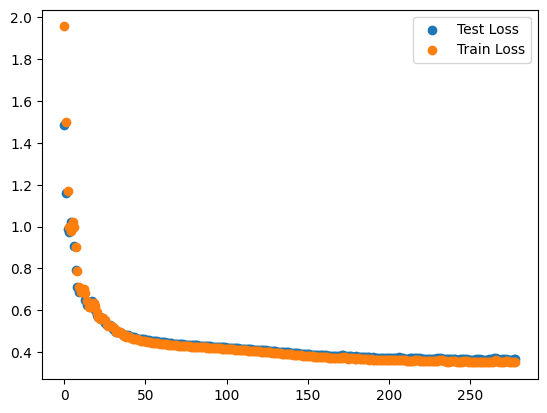

In [18]:
model_2_1 = HousingDNN()
model_2_1.to(device)
num_params = sum(p.numel() for p in model_2_1.parameters())
print(f'Number of parameters: {num_params}')


optimizer = torch.optim.Adam(model_2_1.parameters(), lr=0.01)
loss_function = nn.L1Loss()

epochs = 1000
patience, min_delta, best_test_loss, epochs_without_improvement = 20, 0.0001, float('inf'), 0
test_losses, train_losses, epoch_counts = [], [], []

for i in range(epochs):
    model_2_1.train()
    train_prediction = model_2_1(X_train_tensor)
    train_loss = loss_function(train_prediction, y_train_tensor)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model_2_1.eval()
    with torch.inference_mode():
        test_prediction = model_2_1(X_test_tensor)
        test_loss = loss_function(test_prediction, y_test_tensor)

        if test_loss < (best_test_loss - min_delta):
            best_test_loss = test_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement > patience:
                print(f'Stopping early, best test loss: {best_test_loss:.4f}')
                break
        test_losses.append(test_loss.item())
        train_losses.append(train_loss.item())
        epoch_counts.append(i)
        if i % 10 == 0:
            print(f'Epoch: {i} | Train MAE: {train_loss} | Test MAE: {test_loss}')
        
plt.scatter(epoch_counts, test_losses, label="Test Loss")
plt.scatter(epoch_counts, train_losses, label="Train Loss")
plt.legend()
plt.show()